In [2]:
import requests
import time
import random
import sqlite3
import re
import os

def parse_power(text):
    """Вспомогательная функция для извлечения мощности из текста."""
    if not text: return None
    match = re.search(r'(\d+)\s*[kK][wW]', str(text))
    if match:
        return int(match.group(1))
    return None

def init_db(db_path):
    """Инициализация базы данных SQLite."""
    # Создаем папку, если её нет
    folder = os.path.dirname(db_path)
    if folder and not os.path.exists(folder):
        os.makedirs(folder, exist_ok=True)
        
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS cars (
            id INTEGER PRIMARY KEY,
            brand TEXT,
            model_name TEXT,
            details TEXT,  
            price INTEGER,
            year INTEGER,
            mileage INTEGER,
            fuel TEXT,
            gearbox TEXT,
            power INTEGER,
            url TEXT,
            parsed_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    ''')
    conn.commit()
    return conn

def run_car_parser(target_brands=None, db_path="../data/raw/cars.db", max_pages_per_brand=50):
    """
    Оптимизированная функция парсинга объявлений с sauto.cz.
    """
    if target_brands is None:
        target_brands = [
            'skoda', 'volkswagen', 'bmw', 'audi', 'mercedes-benz', 
            'ford', 'hyundai', 'kia', 'toyota', 'renault', 
            'peugeot', 'seat', 'opel', 'citroen', 'fiat', 
            'mazda', 'honda', 'nissan', 'volvo', 'subaru'
        ]

    conn = init_db(db_path)
    cursor = conn.cursor()

    url = "https://www.sauto.cz/api/v1/items/search"
    
    # Создаем сессию: она держит соединение открытым, что ускоряет парсинг на 15-20%
    session = requests.Session()
    session.headers.update({
        'accept': 'application/json',
        'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    })

    print(f"🚀 СТАРТ: Начинаем сбор данных в {db_path}...")
    total_saved = 0

    for brand in target_brands:
        print(f"\n🚘 --- Марка: {brand.upper()} ---")
        page = 0
        
        while page < max_pages_per_brand:
            params = {
                'limit': 20,
                'offset': page * 20,
                'category_id': 838,
                'condition_seo': 'nove,ojete,predvadeci',
                'manufacturer_model_seo': brand,
            }
            
            try:
                # Используем сессию вместо обычного requests.get
                response = session.get(url, params=params, timeout=(5, 15))
                
                if response.status_code == 200:
                    data = response.json()
                    results = data.get("results", [])
                    
                    if not results:
                        print(f"\n   🪹 {brand.upper()}: Машины закончились на странице {page + 1}.")
                        break
                    
                    for car in results:
                        car_id = car.get("id")
                        name = car.get("name")
                        details = car.get("additional_model_name") 
                        price = car.get("price")
                        
                        date_str = car.get("manufacturing_date") or car.get("in_operation_date") or ""
                        year = int(date_str[:4]) if date_str and date_str[:4].isdigit() else None
                        
                        mileage = car.get("tachometer")
                        fuel = car.get("fuel_cb", {}).get("name")
                        gearbox = car.get("gearbox_cb", {}).get("name")
                        
                        power = car.get("power")
                        if not power: power = parse_power(details)
                        if not power: power = parse_power(name)
                        
                        seo_url = car.get("seo", {}).get("url")
                        full_url = seo_url if seo_url else f"https://www.sauto.cz/osobni/detail/{brand}/car/{car_id}"

                        cursor.execute('''
                            INSERT OR IGNORE INTO cars 
                            (id, brand, model_name, details, price, year, mileage, fuel, gearbox, power, url)
                            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                        ''', (car_id, brand, name, details, price, year, mileage, fuel, gearbox, power, full_url))
                    
                    conn.commit()
                    total_saved += len(results)
                    print(f"\r   ✅ {brand}: стр. {page + 1} сохранена. Всего в базе: {total_saved}", end="", flush=True)
                    page += 1
                    
                    # Ускоренная пауза: от 0.5 до 1.2 секунды
                    time.sleep(random.uniform(0.5, 1.2))
                
                elif response.status_code == 429:
                    # Если сайт ругается на частоту запросов — засыпаем на 20 секунд
                    print(f"\n   ⚠️ Лимит запросов (429)! Спим 20 сек...")
                    time.sleep(20)
                    continue # Пробуем ту же страницу еще раз
                    
                else:
                    print(f"\n   🚨 Ошибка сайта! Код: {response.status_code}")
                    break
                    
            except Exception as e:
                print(f"\n   💥 Ошибка на {brand} (стр. {page + 1}): {e}")
                time.sleep(5)
                break 

    conn.close()
    print(f"\n\n🏁 ГОТОВО! Сбор данных завершен. Всего машин в БД: {total_saved}")
    return total_saved

# Тестовый запуск
run_car_parser(db_path="../data/raw/cars.db") # Измени путь на свой, если нужно

🚀 СТАРТ: Начинаем сбор данных в ../data/raw/cars.db...

🚘 --- Марка: SKODA ---
   ✅ skoda: стр. 50 сохранена. Всего в базе: 1000
🚘 --- Марка: VOLKSWAGEN ---
   ✅ volkswagen: стр. 50 сохранена. Всего в базе: 2000
🚘 --- Марка: BMW ---
   ✅ bmw: стр. 50 сохранена. Всего в базе: 3000
🚘 --- Марка: AUDI ---
   ✅ audi: стр. 50 сохранена. Всего в базе: 4000
🚘 --- Марка: MERCEDES-BENZ ---
   ✅ mercedes-benz: стр. 50 сохранена. Всего в базе: 5000
🚘 --- Марка: FORD ---
   ✅ ford: стр. 50 сохранена. Всего в базе: 6000
🚘 --- Марка: HYUNDAI ---
   ✅ hyundai: стр. 50 сохранена. Всего в базе: 7000
🚘 --- Марка: KIA ---
   ✅ kia: стр. 50 сохранена. Всего в базе: 8000
🚘 --- Марка: TOYOTA ---
   ✅ toyota: стр. 50 сохранена. Всего в базе: 9000
🚘 --- Марка: RENAULT ---
   ✅ renault: стр. 50 сохранена. Всего в базе: 10000
🚘 --- Марка: PEUGEOT ---
   ✅ peugeot: стр. 50 сохранена. Всего в базе: 11000
🚘 --- Марка: SEAT ---
   ✅ seat: стр. 50 сохранена. Всего в базе: 12000
🚘 --- Марка: OPEL ---
   ✅ opel: стр. 5

19230

In [6]:
import pandas as pd
import sqlite3
import numpy as np
import os

# --- 1. НАСТРОЙКА ПУТЕЙ ---
raw_db_path = "../data/raw/cars.db" 
cleaned_dir = "../data/cleaned"
output_file = os.path.join(cleaned_dir, "cars_ready.csv")

# Проверка путей на случай запуска из корня, а не из папки notebooks
if not os.path.exists(raw_db_path) and os.path.exists("data/raw/cars.db"):
    raw_db_path = "data/raw/cars.db"
    cleaned_dir = "data/cleaned"
    output_file = os.path.join(cleaned_dir, "cars_ready.csv")

if not os.path.exists(raw_db_path):
    raise FileNotFoundError(f"❌ База данных не найдена по пути: {raw_db_path}. Сначала запусти парсер!")

# --- 2. ЗАГРУЗКА ДАННЫХ ---
conn = sqlite3.connect(raw_db_path)
df = pd.read_sql("SELECT * FROM cars", conn)
conn.close()

initial_count = len(df)
print(f"📥 Загружено сырых записей: {initial_count}")

# --- 3. ФИЛЬТРАЦИЯ И ПЕРВИЧНАЯ ОЧИСТКА ---

# Удаление дубликатов по ID
df = df.drop_duplicates(subset=['id'])
after_duplicates = len(df)

# Фильтрация выбросов по цене (от 30к до 5 млн крон)
df = df[(df['price'] > 30000) & (df['price'] < 5000000)]
after_price = len(df)

# Удаление записей без года и пробега
df = df.dropna(subset=['year', 'mileage'])
after_nulls = len(df)

# Заполнение пропусков в тексте и очистка пробелов
text_cols = ['brand', 'model_name', 'details', 'fuel', 'gearbox']
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown").astype(str).str.strip()

# --- 4. УМНОЕ ЗАПОЛНЕНИЕ МОЩНОСТИ (Power) ---

# Приводим к числу, ошибки в NaN
df['power'] = pd.to_numeric(df['power'], errors='coerce')

# 🛠️ ИСПРАВЛЕНИЕ БАГА: затираем мощности зарядок электромобилей (22 kW, 24 kW и т.д.)
electric_mask = df['model_name'].str.lower().str.contains('e-tron|zoe|leaf|ev6|tesla|taycan|id\.', na=False)
df.loc[electric_mask & (df['power'] < 50), 'power'] = np.nan

# Убираем общие аномалии мощности (менее 20 кВт и более 600 кВт)
df.loc[(df['power'] < 20) | (df['power'] > 600), 'power'] = np.nan

# Заполнение: медиана по бренду + модели
df['power'] = df['power'].fillna(df.groupby(['brand', 'model_name'])['power'].transform('median'))

# Если все еще пусто: медиана по бренду
df['power'] = df['power'].fillna(df.groupby('brand')['power'].transform('median'))

# Если бренд редкий: общая медиана по всей базе
df['power'] = df['power'].fillna(df['power'].median())

# Страховка для astype(int)
global_median = df['power'].median()
df['power'] = df['power'].fillna(global_median)

# Приводим типы данных к целым числам
df['year'] = df['year'].astype(int)
df['mileage'] = df['mileage'].astype(int)
df['power'] = df['power'].round().astype(int)

# --- 5. СОХРАНЕНИЕ ---

if not os.path.exists(cleaned_dir):
    os.makedirs(cleaned_dir, exist_ok=True)
    print(f"📁 Создана папка: {cleaned_dir}")

df.to_csv(output_file, index=False)

# --- ОТЧЕТ ---
print("-" * 30)
print(f"🧹 Очистка завершена:")
print(f"   - Удалено дубликатов: {initial_count - after_duplicates}")
print(f"   - Удалено по цене: {after_duplicates - after_price}")
print(f"   - Удалено без года/пробега: {after_price - after_nulls}")
print(f"✅ Итого записей готово: {len(df)}")
print(f"💾 Файл сохранен: {output_file}")
print("-" * 30)
print(df[['brand', 'model_name', 'price', 'year', 'power']].head(3))

<>:54: SyntaxWarning: invalid escape sequence '\.'
<>:54: SyntaxWarning: invalid escape sequence '\.'
/var/folders/nf/_plpz1p57pv31n9md8s7b1s40000gn/T/ipykernel_31263/1516036158.py:54: SyntaxWarning: invalid escape sequence '\.'
  electric_mask = df['model_name'].str.lower().str.contains('e-tron|zoe|leaf|ev6|tesla|taycan|id\.', na=False)


📥 Загружено сырых записей: 26063
------------------------------
🧹 Очистка завершена:
   - Удалено дубликатов: 0
   - Удалено по цене: 297
   - Удалено без года/пробега: 0
✅ Итого записей готово: 25766
💾 Файл сохранен: ../data/cleaned/cars_ready.csv
------------------------------
    brand                                    model_name   price  year  power
0  subaru  Subaru Legacy, 2,0 Active Combi, nová spojka   69000  2009    110
1  nissan           Nissan Primera, 1.9 dCi First Class   40000  2003     96
2  nissan  Nissan Pathfinder, 2.5 DCI 140 kw 4x4 7 MÍST  435600  2011    140


📂 Data loaded: 25766 rows


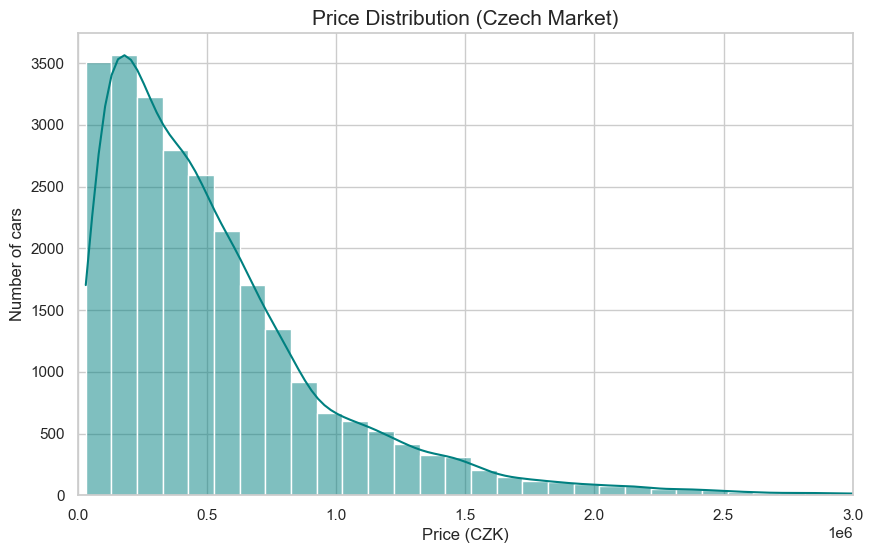

/var/folders/nf/_plpz1p57pv31n9md8s7b1s40000gn/T/ipykernel_31263/265626814.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='brand', y='price', data=df_top, palette='viridis', order=top_brands)


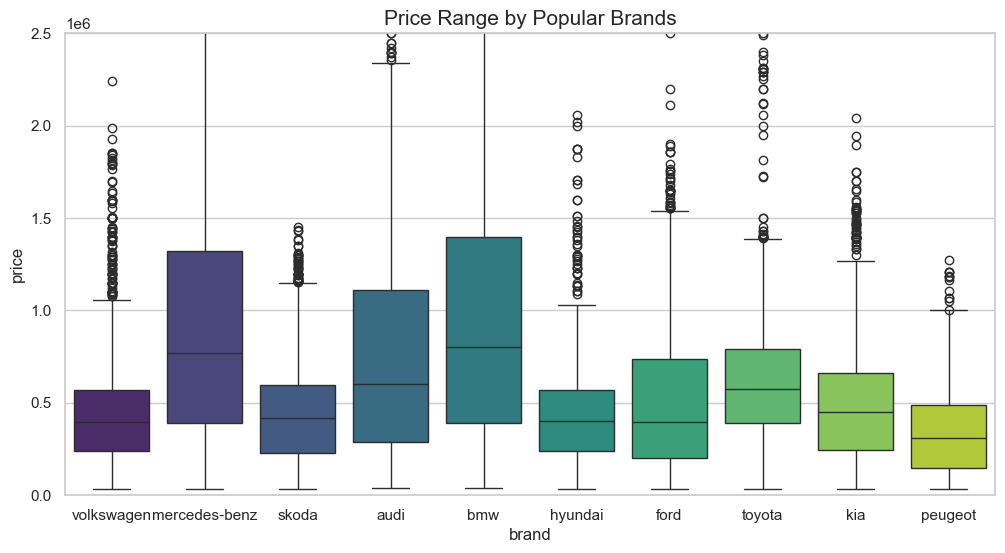

/var/folders/nf/_plpz1p57pv31n9md8s7b1s40000gn/T/ipykernel_31263/265626814.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='body_type_guess', y='price', data=df_body, palette='coolwarm')


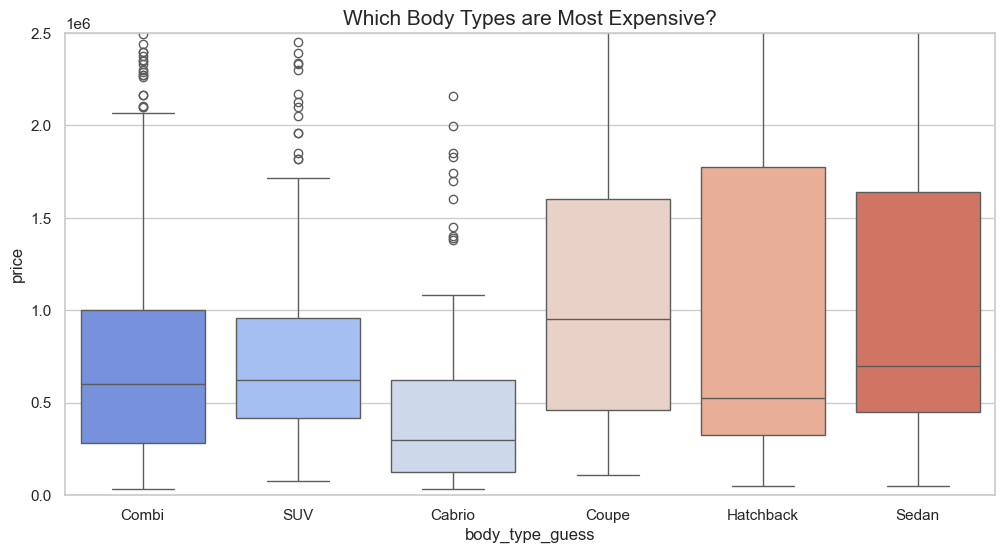

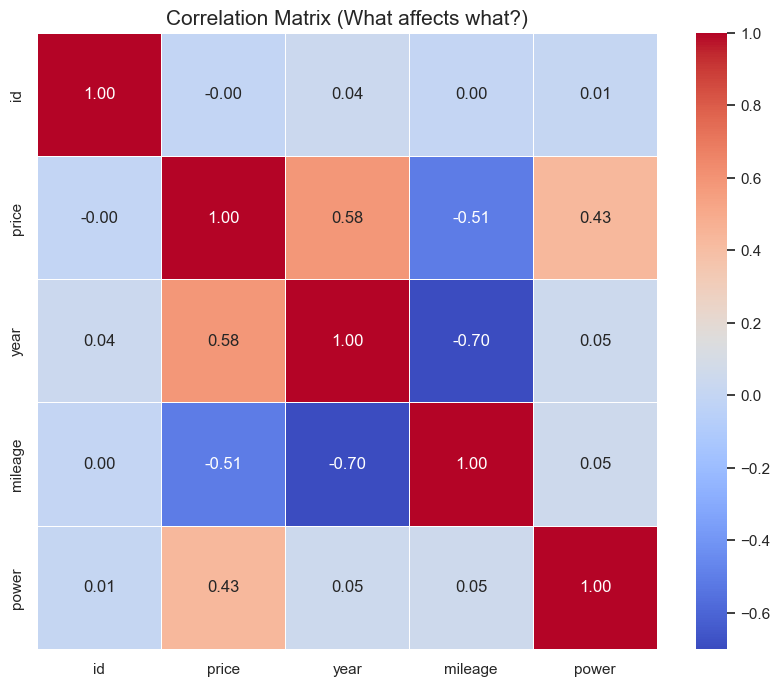

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plot style settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Load data
df = pd.read_csv("../data/cleaned/cars_ready.csv")
print(f"📂 Data loaded: {len(df)} rows")

# --- HACK: Extract Body Type from text for the chart ---
def guess_body_type(text):
    t = str(text).lower()
    if any(x in t for x in ['combi', 'kombi', 'avant', 'variant', 'touring', 'sw']): return 'Combi'
    if any(x in t for x in ['suv', 'cross', 'tiguan', 'kodiaq', 'touareg', 'x5', 'q7', 'cr-v']): return 'SUV'
    if any(x in t for x in ['sedan', 'limuzina', 'limousin']): return 'Sedan'
    if any(x in t for x in ['hatchback', 'fabia', 'golf', 'polo']): return 'Hatchback'
    if any(x in t for x in ['coupe', 'coupé']): return 'Coupe'
    if any(x in t for x in ['cabrio', 'kabrio']): return 'Cabrio'
    return 'Other'

df['body_type_guess'] = df['details'].apply(guess_body_type)

# --- PLOT 1: Histogram (How are prices distributed?) ---
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True, color='teal')
plt.title('Price Distribution (Czech Market)', fontsize=15)
plt.xlabel('Price (CZK)')
plt.ylabel('Number of cars')
plt.xlim(0, 3000000) # Cut the tail > 3M for better visualization
plt.show()

# --- PLOT 2: Boxplot (Price vs Brand) ---
# Taking only Top-10 brands to avoid clutter
top_brands = df['brand'].value_counts().head(10).index
df_top = df[df['brand'].isin(top_brands)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='brand', y='price', data=df_top, palette='viridis', order=top_brands)
plt.title('Price Range by Popular Brands', fontsize=15)
plt.ylim(0, 2500000)
plt.show()

# --- PLOT 3: Boxplot (Price vs Body Type) ---
plt.figure(figsize=(12, 6))
# Remove "Other" category to keep it clean
df_body = df[df['body_type_guess'] != 'Other']
sns.boxplot(x='body_type_guess', y='price', data=df_body, palette='coolwarm')
plt.title('Which Body Types are Most Expensive?', fontsize=15)
plt.ylim(0, 2500000)
plt.show()

# --- PLOT 4: Heatmap (What correlates with what?) ---
# Calculating correlation for numeric values only
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (What affects what?)', fontsize=15)
plt.show()

In [8]:
# Looking at the overall statistics: are there any anomalous maxima/minima
print(df['power'].describe())

# Checking how many zeros or empty strings we have in total
print("Empty values (NaN):", df['power'].isna().sum())
print("Values equal to zero:", (df['power'] == 0).sum())

count    25766.000000
mean       115.104595
std         37.613304
min         22.000000
25%         96.000000
50%        110.000000
75%        136.000000
max        558.000000
Name: power, dtype: float64
Empty values (NaN): 0
Values equal to zero: 0


--- 📊 Статистика по столбцу Power (кВт) ---


count    25766.000000
mean       115.104595
std         37.613304
min         22.000000
25%         96.000000
50%        110.000000
75%        136.000000
max        558.000000
Name: power, dtype: float64


--- 🏎️ Топ-5 машин с МАКСИМАЛЬНОЙ мощностью (ищем верхние аномалии) ---


,brand,model_name,price,year,mileage,power
16497,audi,"Audi RS6, DPH, 4.0 TFSI, 759 koní 558 kw",1980000,2020,95450,558
20042,bmw,"BMW X6, X6M comp, 544kW, odpočet DPH",2000000,2021,83000,544
14423,bmw,"BMW XM, 4.4 505Kw",2499000,2023,86000,505
11711,bmw,"BMW XM, 4.4 V8 480kw B&W,HUD,",2206000,2022,57100,480
1884,kia,"Kia EV6, GT 4x4 478KW+84KWH+SRF",1659900,2025,0,478



--- 🐢 Топ-5 машин с МИНИМАЛЬНОЙ мощностью (ищем нижний мусор/нули) ---


,brand,model_name,price,year,mileage,power
3991,renault,"Renault Kangoo, Z.E. MAXI 22kW 5 míst DPH",249999,2017,71777,22
17060,fiat,"Fiat 500E, 24 kWh, Automat",150000,2014,141146,24
1177,subaru,"Subaru, 1.2, 4WD, 40 kW",85000,1994,999999,40
4654,nissan,"Nissan e-NV200 , 40 kWhNavi,Nez.Top,Výhřev sed+",299000,2021,70432,40
21382,fiat,"Fiat Panda, 1.1i, 40kW, Klima, TOP KM",69999,2009,70128,40


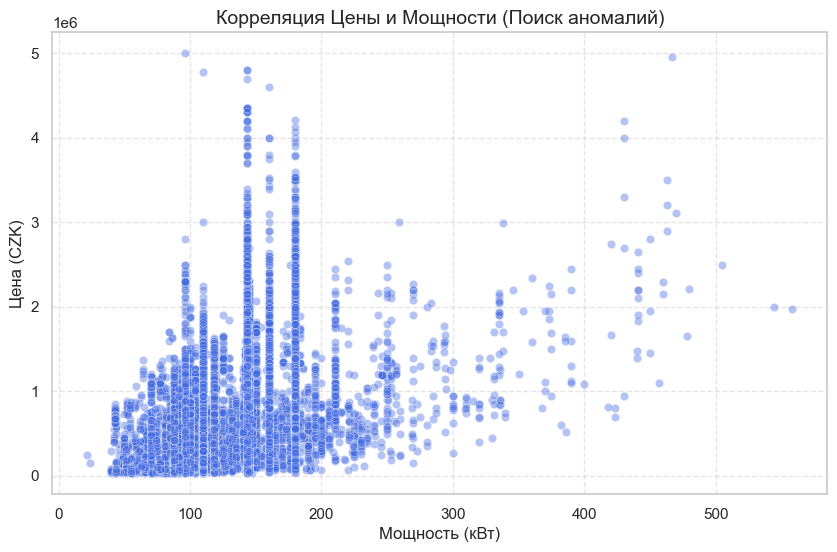

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем данные по правильному пути
df = pd.read_csv('../data/cleaned/cars_ready.csv')

print("--- 📊 Статистика по столбцу Power (кВт) ---")
display(df['power'].describe())

# Добавили 'model_name' в вывод, чтобы понимать, что за машина
print("\n--- 🏎️ Топ-5 машин с МАКСИМАЛЬНОЙ мощностью (ищем верхние аномалии) ---")
display(df[['brand', 'model_name', 'price', 'year', 'mileage', 'power']].sort_values(by='power', ascending=False).head(5))

print("\n--- 🐢 Топ-5 машин с МИНИМАЛЬНОЙ мощностью (ищем нижний мусор/нули) ---")
display(df[['brand', 'model_name', 'price', 'year', 'mileage', 'power']].sort_values(by='power').head(5))

# 2. Отрисовка Scatter Plot (Диаграмма рассеяния)
plt.figure(figsize=(10, 6))
# Сделали точки чуть прозрачнее (alpha=0.4), чтобы видеть плотность
sns.scatterplot(data=df, x='power', y='price', alpha=0.4, color='royalblue')

plt.title('Корреляция Цены и Мощности (Поиск аномалий)', fontsize=14)
plt.xlabel('Мощность (кВт)', fontsize=12)
plt.ylabel('Цена (CZK)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

print("📥 1. Loading clean data...")
# Загружаем датасет из правильной папки
df = pd.read_csv('../data/cleaned/cars_ready.csv')

📥 1. Loading clean data...


In [13]:
print("🧠 2. Feature Engineering (Clusters, Age, Text Mining)...")
# Кластеризация
X_cluster = df[['year', 'mileage', 'power']].copy()
X_scaled = StandardScaler().fit_transform(X_cluster)
df['segment'] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_scaled).astype(str)

# Возраст машины (Текущий год — 2026)
df['car_age'] = 2026 - df['year']

# Вытаскиваем полезные фичи из неструктурированного текста
df['details'] = df['details'].fillna("Unknown").astype(str)
details_lower = df['details'].str.lower()

df['is_4x4'] = details_lower.str.contains(r'4x4|awd|quattro|xdrive|4matic').astype(int)
df['is_automatic'] = details_lower.str.contains(r'automat|dsg|tiptronic|stronic').astype(int)
df['is_sport'] = details_lower.str.contains(r'rs|gti|m-packet|amg|sport|s-line').astype(int)
df['has_led'] = details_lower.str.contains(r'led|matrix|xenon').astype(int)

print("📉 3. Preparing for training...")
# 🛠️ ИСПРАВЛЕНИЕ: Удаляем 'details' И 'model_name', так как в 'model_name' 
# находится длинный текст (например, 'Ford S-MAX...'), который ломает CatBoost
# 🛠️ ИСПРАВЛЕНИЕ: Удаляем ВСЕ текстовые и технические колонки, которые не нужны для обучения
X = df.drop(columns=['price', 'details', 'model_name', 'url', 'parsed_at', 'id'], errors='ignore') 
y = df['price']

# Логарифмируем целевую переменную
y_log = np.log1p(y) 

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Обработка категориальных признаков (теперь список точно совпадает с колонками в X)
cat_features = ['brand', 'fuel', 'gearbox', 'segment'] 
for col in cat_features:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

🧠 2. Feature Engineering (Clusters, Age, Text Mining)...
📉 3. Preparing for training...


In [14]:
import os

print(f"🚀 4. Initializing CatBoost (on {len(X_train)} cars)...")
model = CatBoostRegressor(
    iterations=1500,    
    learning_rate=0.08, 
    depth=7,
    loss_function='RMSE',
    verbose=100,        
    random_seed=42,
    # Направляем логи CatBoost в папку reports
    train_dir='../reports/catboost_info' 
)

model.fit(
    X_train, y_train_log, 
    cat_features=cat_features,
    eval_set=(X_test, y_test_log),
    early_stopping_rounds=50
)

# --- 💾 СОХРАНЕНИЕ МОДЕЛИ НА ДИСК ---
model_dir = "../models"
model_path = os.path.join(model_dir, "catboost_car_model_v2.cbm")

# Проверяем, существует ли папка models, если нет — создаем
if not os.path.exists(model_dir):
    os.makedirs(model_dir, exist_ok=True)
    print(f"📁 Создана папка: {model_dir}")

# Сохраняем модель в нативном формате CatBoost (.cbm)
model.save_model(model_path)

print(f"💾 Модель успешно сохранена на диск по пути: {model_path}")

🚀 4. Initializing CatBoost (on 20612 cars)...
0:	learn: 0.8480268	test: 0.8342770	best: 0.8342770 (0)	total: 65.7ms	remaining: 1m 38s
100:	learn: 0.2983825	test: 0.3055904	best: 0.3055904 (100)	total: 620ms	remaining: 8.59s
200:	learn: 0.2818369	test: 0.2981595	best: 0.2981595 (200)	total: 1.15s	remaining: 7.42s
300:	learn: 0.2737021	test: 0.2954977	best: 0.2954945 (299)	total: 1.68s	remaining: 6.67s
400:	learn: 0.2680277	test: 0.2938827	best: 0.2938827 (400)	total: 2.15s	remaining: 5.9s
500:	learn: 0.2635909	test: 0.2929242	best: 0.2929140 (499)	total: 2.66s	remaining: 5.31s
600:	learn: 0.2594820	test: 0.2921999	best: 0.2921959 (592)	total: 3.19s	remaining: 4.77s
700:	learn: 0.2562138	test: 0.2913882	best: 0.2913882 (700)	total: 3.66s	remaining: 4.17s
800:	learn: 0.2533550	test: 0.2911261	best: 0.2910452 (792)	total: 4.13s	remaining: 3.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.2910451967
bestIteration = 792

Shrink model to first 793 iterations.
💾 Модель у

In [15]:
print("📊 5. Calculating metrics...")
# Reverting log-prices back to real CZK
predictions_real = np.expm1(model.predict(X_test))
y_test_real = np.expm1(y_test_log)

r2 = r2_score(y_test_real, predictions_real)
mae = mean_absolute_error(y_test_real, predictions_real)
mape = mean_absolute_percentage_error(y_test_real, predictions_real)

print("\n" + "="*45)
print(f"🏆 FINAL SUPER-RESULT:")
print(f"📊 Accuracy (R2 Score): {r2:.4f}") 
print(f"💰 Average Error (MAE): {mae:,.0f} CZK")
print(f"🎯 Error Percentage (MAPE): {mape:.2%}")
print("="*45)

📊 5. Calculating metrics...

🏆 FINAL SUPER-RESULT:
📊 Accuracy (R2 Score): 0.7927
💰 Average Error (MAE): 111,934 CZK
🎯 Error Percentage (MAPE): 21.64%


🎨 Plotting graphs...


/var/folders/nf/_plpz1p57pv31n9md8s7b1s40000gn/T/ipykernel_31263/3446258981.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importances", y="Feature Id", data=feat_imp, palette="magma", ax=axes[1])


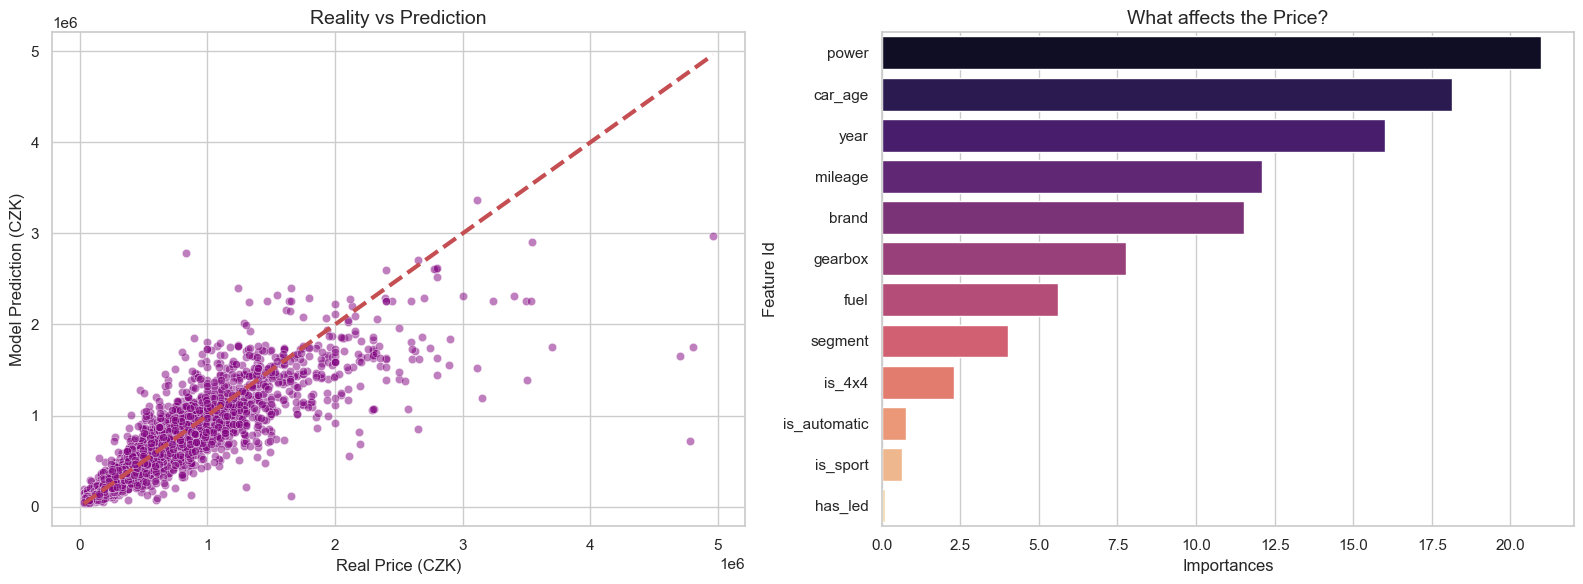

In [16]:
print("🎨 Plotting graphs...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Reality vs Prediction
sns.scatterplot(x=y_test_real, y=predictions_real, alpha=0.5, color='purple', ax=axes[0])
axes[0].plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=3)
axes[0].set_title('Reality vs Prediction', fontsize=14)
axes[0].set_xlabel('Real Price (CZK)')
axes[0].set_ylabel('Model Prediction (CZK)')

# Graph 2: Feature Importance
feat_imp = model.get_feature_importance(prettified=True).head(15)
sns.barplot(x="Importances", y="Feature Id", data=feat_imp, palette="magma", ax=axes[1])
axes[1].set_title('What affects the Price?', fontsize=14)

plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X - all features, y - our target (price)
X = df.drop(columns=['price', 'details'])
y = df['price']

X_encoded = pd.get_dummies(X, drop_first=True)

In [25]:
X_trainlin, X_testlin, y_trainlin, y_testlin = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [26]:
# Finding numeric columns (ignoring boolean/uint8 columns created by get_dummies)
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Creating a scaler object
scaler = StandardScaler()

# Training (fitting) the scaler ONLY on X_train and immediately applying (transforming)
X_trainlin[num_cols] = scaler.fit_transform(X_trainlin[num_cols])

# For X_test ONLY apply (transform), so the model doesn't peek into the future!
X_testlin[num_cols] = scaler.transform(X_testlin[num_cols])

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#X_trainlin, X_testlin, y_trainlin, y_testlin

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    # Training
    model.fit(X_trainlin, y_trainlin) 
    
    # Prediction    
    y_pred = model.predict(X_testlin)
    
    # Collecting metrics
    mae = mean_absolute_error(y_testlin, y_pred)
    r2 = r2_score(y_testlin, y_pred)
    mape = mean_absolute_percentage_error(y_testlin, y_pred)
    
    results.append({"Model": name, "MAE": mae, "R2 Score": r2, "MAPE": mape})

# Transforming results into a DataFrame for convenience
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
display(results_df)

Training Linear Regression...


In [23]:
# Проверим, какие переменные вообще сейчас есть в памяти
# Если X_encoded существует, мы увидим его размер
try:
    print(f"Общий размер X_encoded: {X_encoded.shape}")
    print(f"Количество уникальных колонок: {X_encoded.shape[1]}")
    # Посмотрим на первые 5 названий колонок
    print("Примеры колонок:", X_encoded.columns[:5].tolist())
except NameError:
    print("❌ Переменная X_encoded не найдена! Нужно запустить ячейку с pd.get_dummies")

Общий размер X_encoded: (18816, 39)
Количество уникальных колонок: 39
Примеры колонок: ['year', 'mileage', 'power', 'car_age', 'is_4x4']


In [2]:
from app.ml.preprocessing import load_data_from_db, clean_data

# 1. Загружаем
raw_df = load_data_from_db("data/cars.db")

# 2. Чистим одной командой
df = clean_data(raw_df)

print(df.head())

ModuleNotFoundError: No module named 'app'